# ASSIGNMENT 03 - NEURAL NETWORKS AND REPRESENTATION LEARNING
## Hệ thống 1 - Dự đoán bệnh tiểu đường

**Dataset:** Diabetes Health Indicators Dataset  
**Target:** `Diabetes_binary`

**Mục tiêu**
- 3 mô hình Machine Learning cơ bản.
- Baseline MLP, Deeper MLP và Deep Learning 5 Linear Layers.
- So sánh learning rate `0.001` và `0.01`.
- Accuracy, Precision, Recall, F1-score, ROC-AUC, Confusion Matrix.
- Learned Representation bằng PCA.

In [1]:
import os, copy, random, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0+cpu
Device: cpu


Dataset: Data\diabete.csv
Shape: (253680, 22)
Missing: 0
Duplicate rows: 24206
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Target counts:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


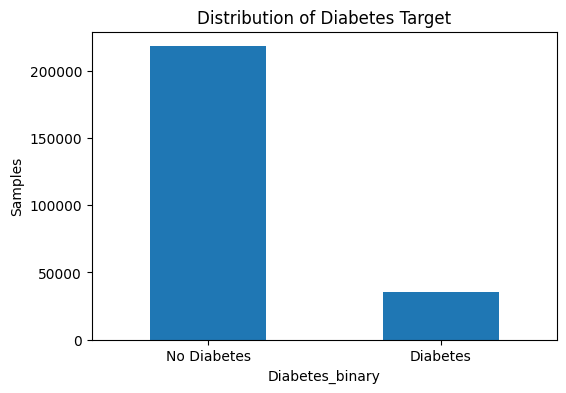

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
# 1. Đọc và khám phá dữ liệu
candidates = [Path("Data/diabete.csv"), Path("Data/diabetes.csv")]
DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy Data/diabete.csv hoặc Data/diabetes.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", df.shape)
print("Missing:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Columns:", df.columns.tolist())

TARGET = "Diabetes_binary"
if TARGET not in df.columns:
    raise ValueError("Dataset không có cột Diabetes_binary")

print("\nTarget counts:")
print(df[TARGET].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)
plt.ylabel("Samples")
plt.title("Distribution of Diabetes Target")
plt.show()

df.head()

In [3]:
# 2. X/y, chia 70/15/15 và chuẩn hóa
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Input dimension:", X_train_scaled.shape[1])

Train: (177576, 21)
Validation: (38052, 21)
Test: (38052, 21)
Input dimension: 21


In [4]:
# 3. Ba mô hình Machine Learning cơ bản
def cls_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score)
    }

logistic_model = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=SEED
)
svm_model = LinearSVC(
    class_weight="balanced", random_state=SEED, max_iter=5000, dual="auto"
)
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_leaf=2,
    class_weight="balanced", random_state=SEED, n_jobs=-1
)

logistic_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

ml_models = {
    "Logistic Regression": (
        logistic_model.predict(X_test_scaled),
        logistic_model.predict_proba(X_test_scaled)[:, 1]
    ),
    "Linear SVM": (
        svm_model.predict(X_test_scaled),
        svm_model.decision_function(X_test_scaled)
    ),
    "Random Forest": (
        rf_model.predict(X_test),
        rf_model.predict_proba(X_test)[:, 1]
    )
}

ml_results = pd.DataFrame([
    {"Model": name, **cls_metrics(y_test, pred, score)}
    for name, (pred, score) in ml_models.items()
])

ml_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7334,0.3129,0.7633,0.4438,0.8216
1,Linear SVM,0.7301,0.3110,0.7710,0.4433,0.8213
2,Random Forest,0.8192,0.3868,0.5081,0.4393,0.8164


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7334,0.3129,0.7633,0.4438,0.8216
1,Linear SVM,0.7301,0.3110,0.7710,0.4433,0.8213
2,Random Forest,0.8192,0.3868,0.5081,0.4393,0.8164


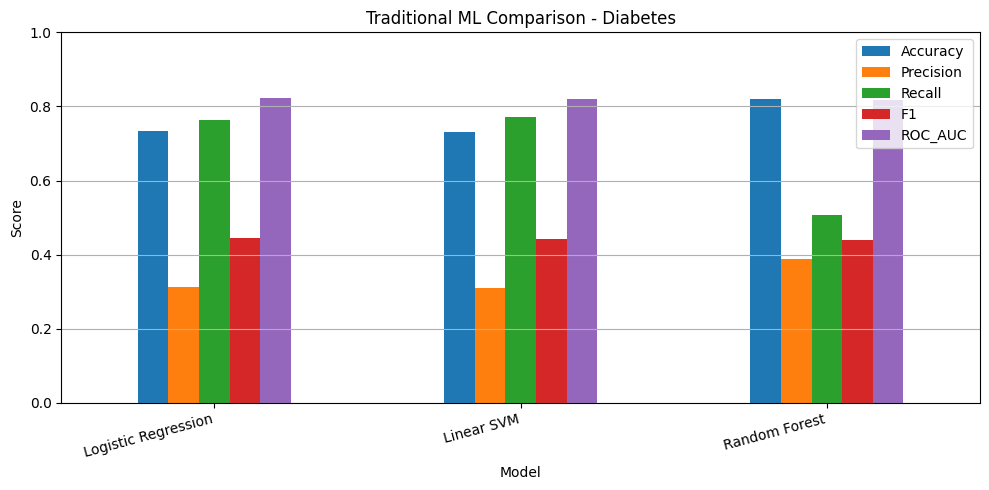

In [5]:
# 4. So sánh 3 ML models
display(ml_results.round(4))

ml_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].plot(kind="bar", figsize=(10, 5))

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Traditional ML Comparison - Diabetes")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [6]:
# 5. Tensor và DataLoader
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

BATCH_SIZE = 512

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def make_train_loader(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)

class_counts = np.bincount(y_train.to_numpy())
class_weights = len(y_train) / (2 * class_counts)
class_weights_tensor = torch.tensor(
    class_weights, dtype=torch.float32, device=device
)

print("Train:", X_train_tensor.shape)
print("Class weights:", class_weights)

Train: torch.Size([177576, 21])
Class weights: [0.58094403 3.58855388]


In [7]:
# 6. Các kiến trúc Neural Network
INPUT_DIM = X_train_scaled.shape[1]

class BaselineMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        return self.net(x)

class DeeperMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x):
        return self.net(x)

class DeepMLP5(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc5 = nn.Linear(8, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return self.fc5(h4)

    def extract_features(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return h1, h2, h3, h4

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for m in [BaselineMLP(INPUT_DIM), DeeperMLP(INPUT_DIM), DeepMLP5(INPUT_DIM)]:
    print(m.__class__.__name__, "-", count_parameters(m), "parameters")

BaselineMLP - 1538 parameters
DeeperMLP - 3554 parameters
DeepMLP5 - 4170 parameters


In [8]:
# 7. Hàm train/evaluate dùng chung
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = correct = total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        pred = outputs.argmax(dim=1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total

def evaluate_dl(model, loader, criterion):
    model.eval()
    total_loss = total = 0
    preds, targets, scores = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)
            prob = torch.softmax(outputs, dim=1)[:, 1]
            pred = outputs.argmax(dim=1)

            total_loss += loss.item() * xb.size(0)
            total += yb.size(0)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
            scores.extend(prob.cpu().numpy())

    metrics = cls_metrics(targets, preds, scores)
    metrics["Loss"] = total_loss / total
    return metrics, np.array(preds), np.array(scores)

def train_model(model, lr, epochs=20, seed=SEED):
    torch.manual_seed(seed)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = make_train_loader(seed)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [], "val_f1": []
    }

    best_f1, best_state, best_epoch = -1, None, 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, loader, criterion, optimizer)
        val_metrics, _, _ = evaluate_dl(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["Loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["Accuracy"])
        history["val_f1"].append(val_metrics["F1"])

        if val_metrics["F1"] > best_f1:
            best_f1 = val_metrics["F1"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train Loss {train_loss:.4f} | "
                f"Val Loss {val_metrics['Loss']:.4f} | "
                f"Val F1 {val_metrics['F1']:.4f}"
            )

    model.load_state_dict(best_state)
    return model, history, best_epoch, best_f1

def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history["train_loss"], label="Train")
    ax[0].plot(history["val_loss"], label="Validation")
    ax[0].set_title(f"{title} - Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(history["train_acc"], label="Train")
    ax[1].plot(history["val_acc"], label="Validation")
    ax[1].set_title(f"{title} - Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid()

    plt.tight_layout()
    plt.show()

## 8. Cấu hình thí nghiệm Neural Network

- Batch size: **512**
- Epochs: **20**
- Loss: **Weighted CrossEntropyLoss**
- Optimizer: **Adam**
- Activation: **ReLU**
- Model selection: **Validation F1-score**

Experiments:
1. Baseline: `d → 64 → 2`
2. Deeper: `d → 64 → 32 → 2`
3. 5-Layer: `d → 64 → 32 → 16 → 8 → 2`, so sánh LR `0.001` và `0.01`.

In [9]:
# 9. Experiment 1 - Baseline
baseline_model, baseline_history, baseline_epoch, baseline_val_f1 = train_model(
    BaselineMLP(INPUT_DIM), lr=0.001
)
print("Best epoch:", baseline_epoch)
print("Best validation F1:", round(baseline_val_f1, 4))

Epoch 05/20 | Train Loss 0.5008 | Val Loss 0.5057 | Val F1 0.4388
Epoch 10/20 | Train Loss 0.4988 | Val Loss 0.5060 | Val F1 0.4374
Epoch 15/20 | Train Loss 0.4979 | Val Loss 0.5053 | Val F1 0.4407
Epoch 20/20 | Train Loss 0.4972 | Val Loss 0.5053 | Val F1 0.4428
Best epoch: 6
Best validation F1: 0.4461


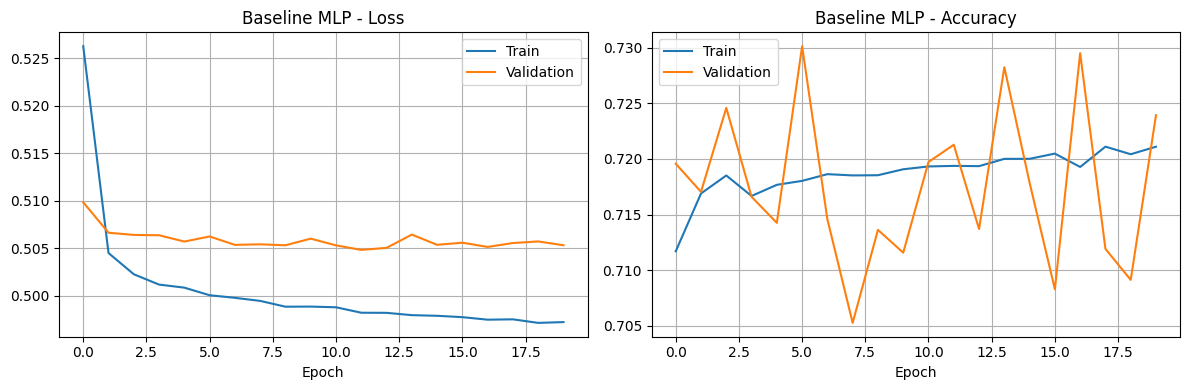

In [10]:
plot_history(baseline_history, "Baseline MLP")

In [11]:
# 10. Experiment 2 - Deeper
deeper_model, deeper_history, deeper_epoch, deeper_val_f1 = train_model(
    DeeperMLP(INPUT_DIM), lr=0.001
)
print("Best epoch:", deeper_epoch)
print("Best validation F1:", round(deeper_val_f1, 4))

Epoch 05/20 | Train Loss 0.5005 | Val Loss 0.5061 | Val F1 0.4464
Epoch 10/20 | Train Loss 0.4973 | Val Loss 0.5059 | Val F1 0.4384
Epoch 15/20 | Train Loss 0.4950 | Val Loss 0.5061 | Val F1 0.4373
Epoch 20/20 | Train Loss 0.4931 | Val Loss 0.5064 | Val F1 0.4386
Best epoch: 6
Best validation F1: 0.4485


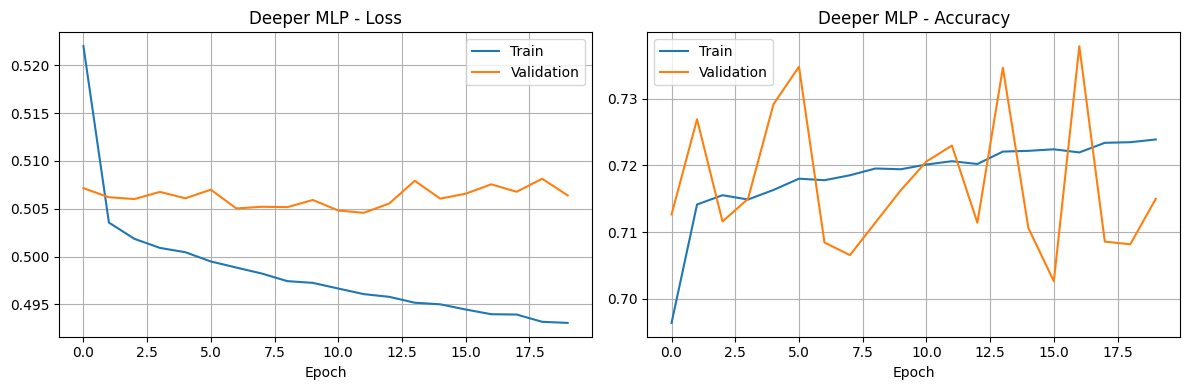

In [12]:
plot_history(deeper_history, "Deeper MLP")

In [13]:
# 11. Experiment 3 - 5 Layers, hai learning rate
deep5_lr001, hist_lr001, epoch_lr001, val_f1_lr001 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.001
)

deep5_lr01, hist_lr01, epoch_lr01, val_f1_lr01 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.01
)

print("LR 0.001 -> Val F1:", round(val_f1_lr001, 4))
print("LR 0.01  -> Val F1:", round(val_f1_lr01, 4))

if val_f1_lr001 >= val_f1_lr01:
    final_dl_model, final_dl_lr = deep5_lr001, 0.001
else:
    final_dl_model, final_dl_lr = deep5_lr01, 0.01

Epoch 05/20 | Train Loss 0.5011 | Val Loss 0.5069 | Val F1 0.4466
Epoch 10/20 | Train Loss 0.4981 | Val Loss 0.5057 | Val F1 0.4374
Epoch 15/20 | Train Loss 0.4958 | Val Loss 0.5065 | Val F1 0.4397
Epoch 20/20 | Train Loss 0.4936 | Val Loss 0.5068 | Val F1 0.4342
Epoch 05/20 | Train Loss 0.5027 | Val Loss 0.5074 | Val F1 0.4393
Epoch 10/20 | Train Loss 0.5009 | Val Loss 0.5075 | Val F1 0.4275
Epoch 15/20 | Train Loss 0.4977 | Val Loss 0.5082 | Val F1 0.4267
Epoch 20/20 | Train Loss 0.4958 | Val Loss 0.5079 | Val F1 0.4243
LR 0.001 -> Val F1: 0.4489
LR 0.01  -> Val F1: 0.445


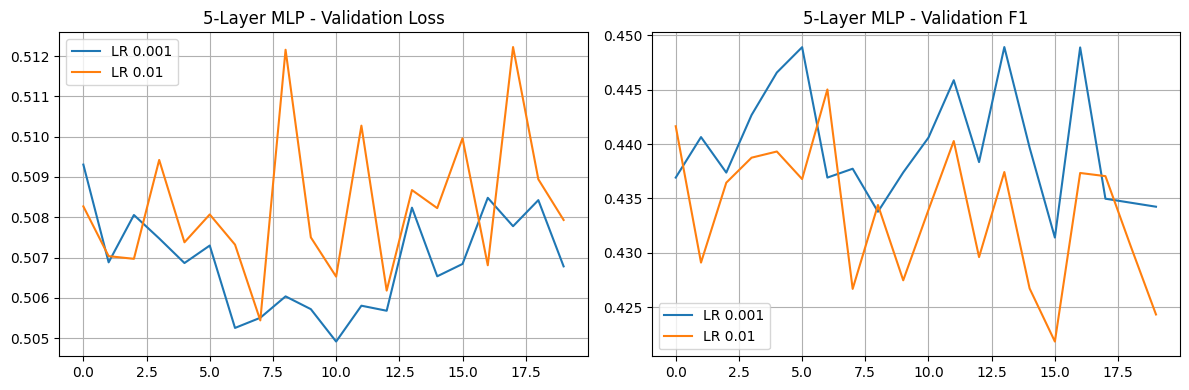

In [14]:
# 12. So sánh learning rate
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_lr001["val_loss"], label="LR 0.001")
ax[0].plot(hist_lr01["val_loss"], label="LR 0.01")
ax[0].set_title("5-Layer MLP - Validation Loss")
ax[0].legend()
ax[0].grid()

ax[1].plot(hist_lr001["val_f1"], label="LR 0.001")
ax[1].plot(hist_lr01["val_f1"], label="LR 0.01")
ax[1].set_title("5-Layer MLP - Validation F1")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

In [15]:
# 13. Đánh giá Neural Network trên Test
criterion_test = nn.CrossEntropyLoss(weight=class_weights_tensor)

dl_models = [
    ("Baseline MLP", baseline_model, f"{INPUT_DIM}-64-2", 0.001, baseline_epoch),
    ("Deeper MLP", deeper_model, f"{INPUT_DIM}-64-32-2", 0.001, deeper_epoch),
    ("5-Layer MLP (0.001)", deep5_lr001, f"{INPUT_DIM}-64-32-16-8-2", 0.001, epoch_lr001),
    ("5-Layer MLP (0.01)", deep5_lr01, f"{INPUT_DIM}-64-32-16-8-2", 0.01, epoch_lr01),
]

dl_rows = []
dl_predictions = {}

for name, model, arch, lr, epoch in dl_models:
    metrics, pred, score = evaluate_dl(model, test_loader, criterion_test)
    dl_predictions[name] = pred
    dl_rows.append({
        "Model": name,
        "Architecture": arch,
        "Parameters": count_parameters(model),
        "Learning Rate": lr,
        "Best Epoch": epoch,
        **metrics
    })

dl_results = pd.DataFrame(dl_rows)
dl_results.round(4)

,Model,Architecture,Parameters,Learning Rate,Best Epoch,Accuracy,Precision,Recall,F1,ROC_AUC,Loss
0,Baseline MLP,21-64-2,1538,0.001,6,0.7340,0.3158,0.7791,0.4494,0.8292,0.5041
1,Deeper MLP,21-64-32-2,3554,0.001,6,0.7377,0.3182,0.7722,0.4507,0.8291,0.5050
2,5-Layer MLP (0.001),21-64-32-16-8-2,4170,0.001,14,0.7401,0.3189,0.7616,0.4495,0.8280,0.5074
3,5-Layer MLP (0.01),21-64-32-16-8-2,4170,0.010,7,0.7316,0.3138,0.7801,0.4475,0.8287,0.5053


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,Deeper MLP,0.7377,0.3182,0.7722,0.4507,0.8291
5,5-Layer MLP (0.001),0.7401,0.3189,0.7616,0.4495,0.8280
3,Baseline MLP,0.7340,0.3158,0.7791,0.4494,0.8292
6,5-Layer MLP (0.01),0.7316,0.3138,0.7801,0.4475,0.8287
0,Logistic Regression,0.7334,0.3129,0.7633,0.4438,0.8216
1,Linear SVM,0.7301,0.3110,0.7710,0.4433,0.8213
2,Random Forest,0.8192,0.3868,0.5081,0.4393,0.8164


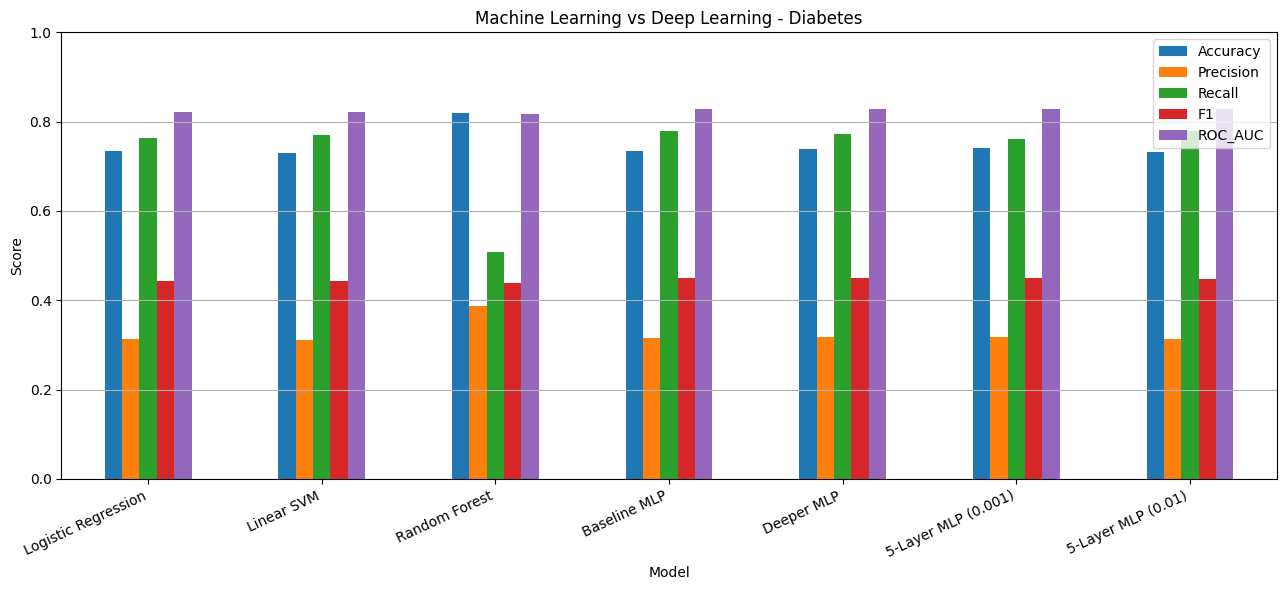

In [16]:
# 14. Tổng hợp ML và DL
all_results = pd.concat(
    [
        ml_results,
        dl_results[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]
    ],
    ignore_index=True
)

display(all_results.sort_values("F1", ascending=False).round(4))

all_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].plot(kind="bar", figsize=(13, 6))

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Machine Learning vs Deep Learning - Diabetes")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [17]:
# Best Result
best_model = all_results.loc[
    all_results["F1"].idxmax()
]

print("BEST MODEL")
print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1-score  : {best_model['F1']:.4f}")
print(f"ROC-AUC   : {best_model['ROC_AUC']:.4f}")

BEST MODEL
Model     : Deeper MLP
Accuracy  : 0.7377
Precision : 0.3182
Recall    : 0.7722
F1-score  : 0.4507
ROC-AUC   : 0.8291


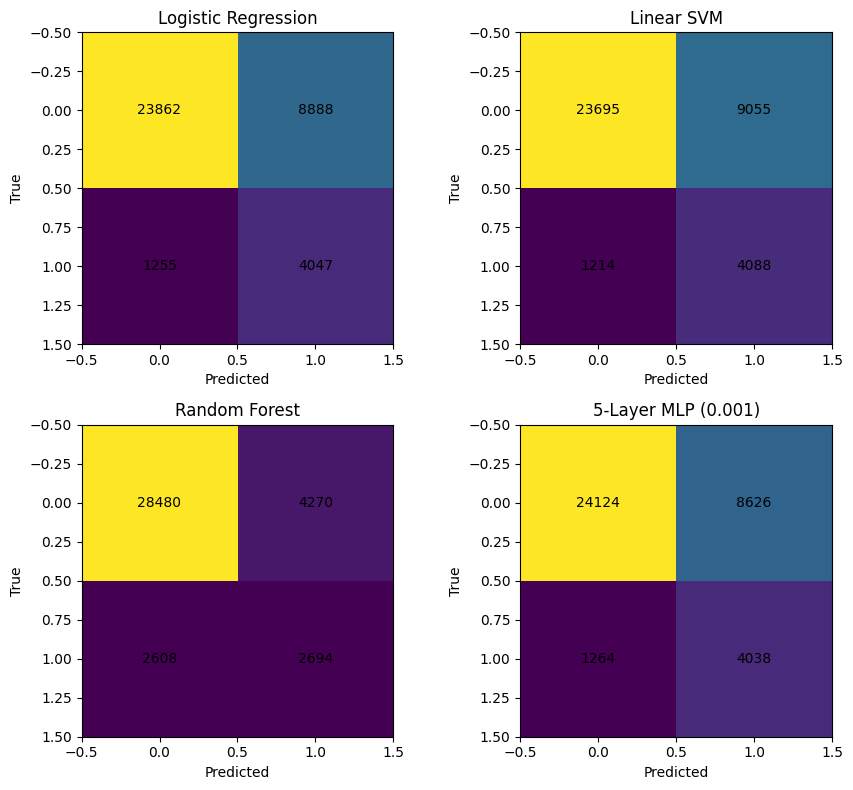

In [18]:
# 15. Confusion Matrix: 3 ML models + final 5-layer
final_name = "5-Layer MLP (0.001)" if final_dl_lr == 0.001 else "5-Layer MLP (0.01)"

cm_items = [
    ("Logistic Regression", ml_models["Logistic Regression"][0]),
    ("Linear SVM", ml_models["Linear SVM"][0]),
    ("Random Forest", ml_models["Random Forest"][0]),
    (final_name, dl_predictions[final_name]),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for ax, (name, pred) in zip(axes.ravel(), cm_items):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

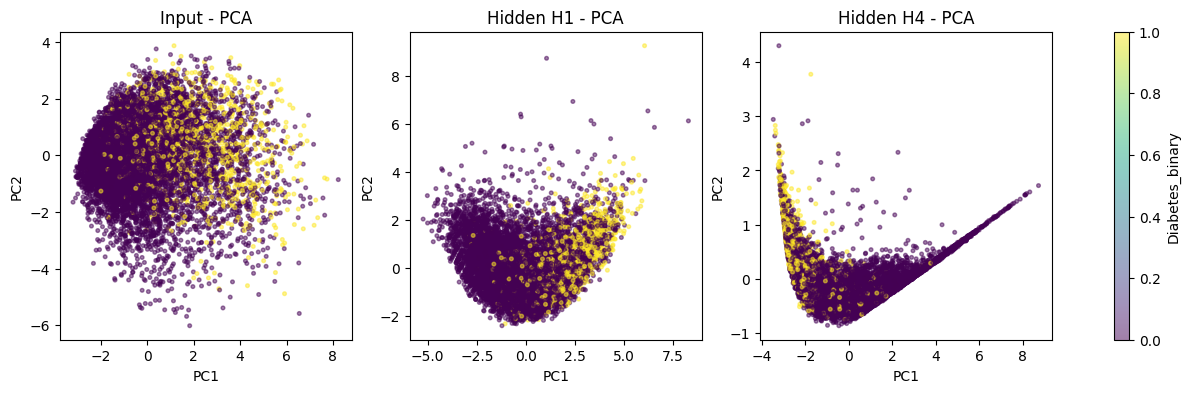

Input: (38052, 21)
H1: (38052, 64)
H4: (38052, 8)


In [19]:
# 16. Learned Representation + PCA
final_dl_model.eval()

with torch.no_grad():
    h1, h2, h3, h4 = final_dl_model.extract_features(X_test_tensor.to(device))

h1_np = h1.cpu().numpy()
h4_np = h4.cpu().numpy()

N = min(10000, len(X_test_scaled))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test_scaled), size=N, replace=False)
y_pca = y_test.to_numpy()[idx]

representations = [
    ("Input", X_test_scaled[idx]),
    ("Hidden H1", h1_np[idx]),
    ("Hidden H4", h4_np[idx]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, rep) in zip(axes, representations):
    pca_2d = PCA(n_components=2).fit_transform(rep)
    sc = ax.scatter(pca_2d[:, 0], pca_2d[:, 1], c=y_pca, s=7, alpha=0.5)
    ax.set_title(f"{name} - PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.colorbar(sc, ax=axes.ravel().tolist(), label="Diabetes_binary")
plt.show()

print("Input:", X_test_scaled.shape)
print("H1:", h1_np.shape)
print("H4:", h4_np.shape)

In [20]:
# 17. Lưu mô hình
os.makedirs("models", exist_ok=True)

torch.save(final_dl_model.state_dict(), "models/diabetes_deep_mlp_5layers.pth")
joblib.dump(scaler, "models/diabetes_scaler.joblib")

joblib.dump(
    {
        "input_dim": INPUT_DIM,
        "architecture": f"{INPUT_DIM}-64-32-16-8-2",
        "learning_rate": final_dl_lr,
        "target": TARGET,
        "features": X.columns.tolist()
    },
    "models/diabetes_model_info.joblib"
)

print("Selected 5-layer LR:", final_dl_lr)
print("Model saved:", os.path.exists("models/diabetes_deep_mlp_5layers.pth"))

Selected 5-layer LR: 0.001
Model saved: True


## 18. Thảo luận kết quả

Sau khi chạy notebook, dựa vào số liệu thật để nhận xét:
- Model nào có F1-score/Recall tốt nhất?
- Baseline và Deeper MLP khác nhau thế nào?
- Learning rate nào phù hợp hơn?
- Có overfitting không?
- Hidden representation thay đổi thế nào từ Input → H1 → H4?

**Lưu ý:** dữ liệu mất cân bằng nên không đánh giá chỉ bằng Accuracy.

## 19. Kết luận

Notebook đã so sánh 3 mô hình Machine Learning với các Neural Network cho bài toán dự đoán tiểu đường.

Deep Learning 5 Linear Layers:

**Input → 64 → 32 → 16 → 8 → 2**

PCA được dùng để trực quan hóa learned representation qua các hidden layers.